In [1]:
# analysis specific imports
import spacenet as sn

# general imports
import numpy as np
import pandas as pd 
import networkx as nx
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

plt.rcParams['figure.dpi'] = 200

max_r=500

netPCF_kwargs = dict(spatial_kernel_bandwidth=60,
                    spatial_kernel_n=2,
                    r_min=0, 
                    r_max=max_r, 
                    r_step=10,
                    edge_weight_name='Distance', 
                    return_confidence_interval=True,
                    low_memory=False,
                    verbose=True,
                    n_jobs=-1) 


weighted_pcf_kwargs = dict(marker_kernel_bandwidth=0.5,
                           marker_kernel_n=0.5,
                           marker_min=-1,
                           marker_max=1,
                           marker_step=1,
                           spatial_kernel_bandwidth=60,
                            spatial_kernel_n=2,
                            r_min=0, 
                            r_max=max_r, 
                            r_step=10,
                            edge_weight_name='Distance', 
                            return_confidence_interval=True,
                            low_memory=False,
                            verbose=True,
                            n_jobs=-1)

scatter_kwargs=dict(linewidths=0.1,edgecolors='black')
visualise_paras = dict(edge_width=0.2,marker_size=20,add_legend=False,edge_weight_name=None,scatter_kwargs=scatter_kwargs) 
visualise_paras_cont = dict(edge_width=0,add_legend=False,edge_weight_name=None) 
scalebar_kwargs = dict(size=200, label='',loc='lower right',pad = 1.5,frameon=False,size_vertical=10,zorder=1000)

categorical_threshold = 0.6


In [2]:
spiral_df = pd.read_csv('../data/synthetic_data/spiral_domain.csv')
points_spiral = spiral_df[['x','y']].to_numpy() 
rand_labels_spiral = spiral_df['Random marker (categorical)']
periodic_labels_spiral = spiral_df['Marker (categorical)']
rand_labels_spiral_cont = spiral_df['Random marker (continuous)']
periodic_labels_spiral_cont = -spiral_df['Marker (continuous)']

periodic_labels_spiral = []
for p in periodic_labels_spiral_cont:
    if p >=categorical_threshold:
        periodic_labels_spiral.append('A')
    elif p <= -categorical_threshold:
        periodic_labels_spiral.append('B')
    else:
        periodic_labels_spiral.append('C')
periodic_labels_spiral = np.array(periodic_labels_spiral)


points_spiral = spiral_df[['x','y']].to_numpy() 
points_spiral= (points_spiral/2 + 500) +np.array([-25,50])

sp_dist_threshold = 60
distance_from_center_spiral = np.linalg.norm(points_spiral - np.array([500,600]), axis=1)
centre_nodes_spiral = np.where(distance_from_center_spiral<sp_dist_threshold)[0]
not_central_nodes_spiral = np.where(distance_from_center_spiral>=sp_dist_threshold)[0]
periodic_labels_spiral_cont_not_center = periodic_labels_spiral_cont[distance_from_center_spiral>=sp_dist_threshold]

G_spiral = sn.utils.spatial_network_from_points(points_spiral,network_type='delaunay',max_edge_distance=60)


In [4]:
# Parameters for the cylinder
height = 1000   # Height of the cylinder
radius = 215*(2/np.pi)   # Radius of the cylinder
lambda_density = 0.0001  # Intensity (points per unit volume)
# Calculate the expected number of points based on the surface area of the hollow cylinder
surface_area = np.pi * (radius**2) * height  # Lateral surface area of the cylinder
num_points = np.random.poisson(lambda_density * surface_area)  # Number of points from Poisson process
osc_scale=0

# Generate points
z = np.random.uniform(0, height, num_points)# Random heights along the cylinder
theta = np.random.uniform(0, 2 * np.pi, num_points)  # Random angles around the cylinder
x = radius * np.cos(theta) + np.cos(osc_scale*z)  # X-coordinates (fixed radius for hollow cylinder)
y = radius * np.sin(theta) + np.sin(osc_scale*z) # Y-coordinates (fixed radius for hollow cylinder)


# Combine into a single array of points
cylinder_points = np.vstack((x, y, z)).T

bottom_labels=[]
for p in cylinder_points:
    if p[2] < 20:
        bottom_labels.append('Base')
    else:
        bottom_labels.append('Surface')

bottom_labels = np.array(bottom_labels)
bottom_indices = np.where(bottom_labels == 'Base')[0]


G_cyclinder=sn.utils.spatial_network_from_points(cylinder_points,network_type='Delaunay',min_edge_distance=0,max_edge_distance=25)

surface_from_base_distance = nx.multi_source_dijkstra_path_length(G_cyclinder, sources=set(bottom_indices), cutoff=None, weight='Distance')
distance_from_base = np.zeros(len(cylinder_points))
for node in surface_from_base_distance:
    
    distance_from_base[int(node)] = surface_from_base_distance[node]

# Convert points to cylindrical coordinates
cylinder_points_cylindrical = np.zeros((cylinder_points.shape[0], 3))
cylinder_points_cylindrical[:, 0] = np.sqrt(cylinder_points[:, 0]**2 + cylinder_points[:, 1]**2)  # Radius
cylinder_points_cylindrical[:, 1] = np.arctan2(cylinder_points[:, 1], cylinder_points[:, 0])  # Angle
cylinder_points_cylindrical[:, 2] = cylinder_points[:, 2]  # Height

#pattern_along_cylinder = np.sin(2*cylinder_points_cylindrical[:, 1]) * np.sin(2*np.pi*cylinder_points[:, 2]/400 )
pattern_along_cylinder = np.sin( 4*np.pi* (cylinder_points[:, 2] / (2*radius*np.pi)) )* np.sin(2*cylinder_points_cylindrical[:, 1])

#pattern_along_cylinder_cat = np.where(pattern_along_cylinder >= 0, 'A', 'B')

pattern_along_cylinder_cat = []

for p in pattern_along_cylinder:
    if p >=categorical_threshold:
        pattern_along_cylinder_cat.append('A')
    elif p <=-categorical_threshold:
        pattern_along_cylinder_cat.append('B')
    else:
        pattern_along_cylinder_cat.append('C')
pattern_along_cylinder_cat = np.array(pattern_along_cylinder_cat)

nodes_at_low_cyclinder = np.where(np.logical_and(pattern_along_cylinder<-0.9, np.logical_and(cylinder_points[:,2]>450,cylinder_points[:,2]<600)))[0]

all_other_nodes_cyclinder=np.setdiff1d(np.arange(len(cylinder_points)),nodes_at_low_cyclinder)  
pattern_along_cylinder_other = pattern_along_cylinder[all_other_nodes_cyclinder]

cylinder_points = cylinder_points + np.array([radius,radius,0])

In [6]:
length = 1000   

# Parameters for the Poisson point process
lambda_density = 0.00002  # Intensity (points per unit volume)
volume = length ** 3  # Volume of the 3D space
num_points = np.random.poisson(lambda_density * volume)  # Number of points from Poisson process

# Generate points in 3D space
points_3d = np.random.uniform(0, length, (num_points, 3))

# Filter out points greater than 500 distance from the center (500, 500, 500)
center = np.array([length/2, length/2, length/2])
distances = np.linalg.norm(points_3d - center, axis=1)
filtered_points_sphere = points_3d[distances <= length/2]

G_sphere=sn.utils.spatial_network_from_points(filtered_points_sphere,network_type='Delaunay',min_edge_distance=0,max_edge_distance=60)

periodic_pattern_sphere = np.zeros(len(filtered_points_sphere))
# Create a periodic pattern in the sphere based on distance from the center
distance_from_center = np.linalg.norm(filtered_points_sphere - center, axis=1)
periodic_pattern_sphere = np.sin(4*np.pi*  (distance_from_center+radius/2) / (2*radius*np.pi))

periodic_pattern_sphere_cat = []
for i, p in enumerate(periodic_pattern_sphere):
    if p >=categorical_threshold and distance_from_center[i]< 250 :
        periodic_pattern_sphere_cat.append(1)
    elif p <= -categorical_threshold:
        periodic_pattern_sphere_cat.append(2)
        
    else:
        periodic_pattern_sphere_cat.append(3)
        
periodic_pattern_sphere_cat = np.array(periodic_pattern_sphere_cat)

nodes_in_center = np.where(distance_from_center <= 50)[0]
all_other_nodes_sphere=np.setdiff1d(np.arange(len(filtered_points_sphere)),nodes_in_center)  
pattern_along_sphere_other = periodic_pattern_sphere[all_other_nodes_sphere]


### cross-netPCF

In [9]:
### spiral
r_spiral,g_spiral,CI_spiral = sn.point_patterns.cross_pair_correlation_function(G_spiral,
                                                                                nodes_a=np.where(periodic_labels_spiral=='A')[0],
                                                                                nodes_b=np.where(periodic_labels_spiral=='B')[0],
                                                                                **netPCF_kwargs)  

### cylinder
r_cylinder,g_cylinder,CI_cylinder = sn.point_patterns.cross_pair_correlation_function(G_cyclinder,
                                                                                    nodes_a=np.where(pattern_along_cylinder_cat=='A')[0],
                                                                                    nodes_b=np.where(pattern_along_cylinder_cat=='B')[0],
                                                                                    **netPCF_kwargs)

### sphere
r_sphere,g_sphere,CI_sphere = sn.point_patterns.cross_pair_correlation_function(G_sphere,
                                                                                nodes_a=np.where(periodic_pattern_sphere_cat==1)[0],
                                                                                nodes_b=np.where(periodic_pattern_sphere_cat==2)[0],
                                                                                **netPCF_kwargs)

Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 326/326 [00:05<00:00, 56.16contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 899/899 [00:15<00:00, 59.09contributions/s] 


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 78/78 [00:19<00:00,  4.08contributions/s]


Computing confidence intervals via spatial bootstrap...


### netPCF

In [10]:
### spiral
r_spiral_back,g_spiral_back,CI_spiral_back = sn.point_patterns.cross_pair_correlation_function(G_spiral,**netPCF_kwargs)  

### cylinder
r_cylinder_back,g_cylinder_back,CI_cylinder_back = sn.point_patterns.cross_pair_correlation_function(G_cyclinder,**netPCF_kwargs)

### sphere
r_sphere_back,g_sphere_back,CI_sphere_back = sn.point_patterns.cross_pair_correlation_function(G_sphere,**netPCF_kwargs)


Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 1159/1159 [00:05<00:00, 216.42contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 5959/5959 [00:50<00:00, 118.75contributions/s]


Computing confidence intervals via spatial bootstrap...
Computing node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 10161/10161 [02:01<00:00, 83.84contributions/s]


Computing confidence intervals via spatial bootstrap...


### weighted-netPCF

In [11]:
### spiral
tau_spiral_cont,r_spiral_cont,g_spiral_cont,CI_spiral_cont=sn.point_patterns.weighted_pair_correlation_function(G_spiral,
                                   node_label_name_b=periodic_labels_spiral_cont_not_center.to_numpy(),
                                   nodes_a=centre_nodes_spiral,
                                   nodes_b=not_central_nodes_spiral, 
                                   **weighted_pcf_kwargs)

### cylinder
tau_cyclinder_cont,r_cyclinder_cont,g_cyclinder_cont,CI_cyclinder_cont=sn.point_patterns.weighted_pair_correlation_function(G_cyclinder,
                                   node_label_name_b=pattern_along_cylinder_other,
                                   nodes_a=nodes_at_low_cyclinder,
                                   nodes_b=all_other_nodes_cyclinder, 
                                   **weighted_pcf_kwargs)

### sphere
tau_sphere_cont,r_sphere_cont,g_sphere_cont,CI_sphere_cont=sn.point_patterns.weighted_pair_correlation_function(G_sphere,
                                   node_label_name_b=pattern_along_sphere_other,
                                   nodes_a=nodes_in_center,
                                   nodes_b=all_other_nodes_sphere, 
                                   **weighted_pcf_kwargs)
    

Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 25/25 [00:05<00:00,  4.30contributions/s]


Computing confidence intervals via spatial bootstrap...
Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 35/35 [00:06<00:00,  5.21contributions/s]


Computing confidence intervals via spatial bootstrap...
Getting cached node-node distances...
Computing contributions in parallel using 12 cores...


Computing contributions: 100%|██████████| 12/12 [00:06<00:00,  1.84contributions/s]

Computing confidence intervals via spatial bootstrap...


### visualise domains and pcf curves (categorical)

/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/netPCF/spacenet/spacenet/utils/plot_spatial_network.py:230: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(points[:, 0], points[:, 1],color='grey', s=marker_size,zorder=100,**scatter_kwargs)
/var/folders/mh/z12kkpjj6pjg5_vrjp8t1xd40000gn/T/ipykernel_37480/1637826021.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax9.scatter(filtered_points_sphere[mask, 0], filtered_points_sphere[mask, 1], filtered_points_sphere[mask, 2],
/opt/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


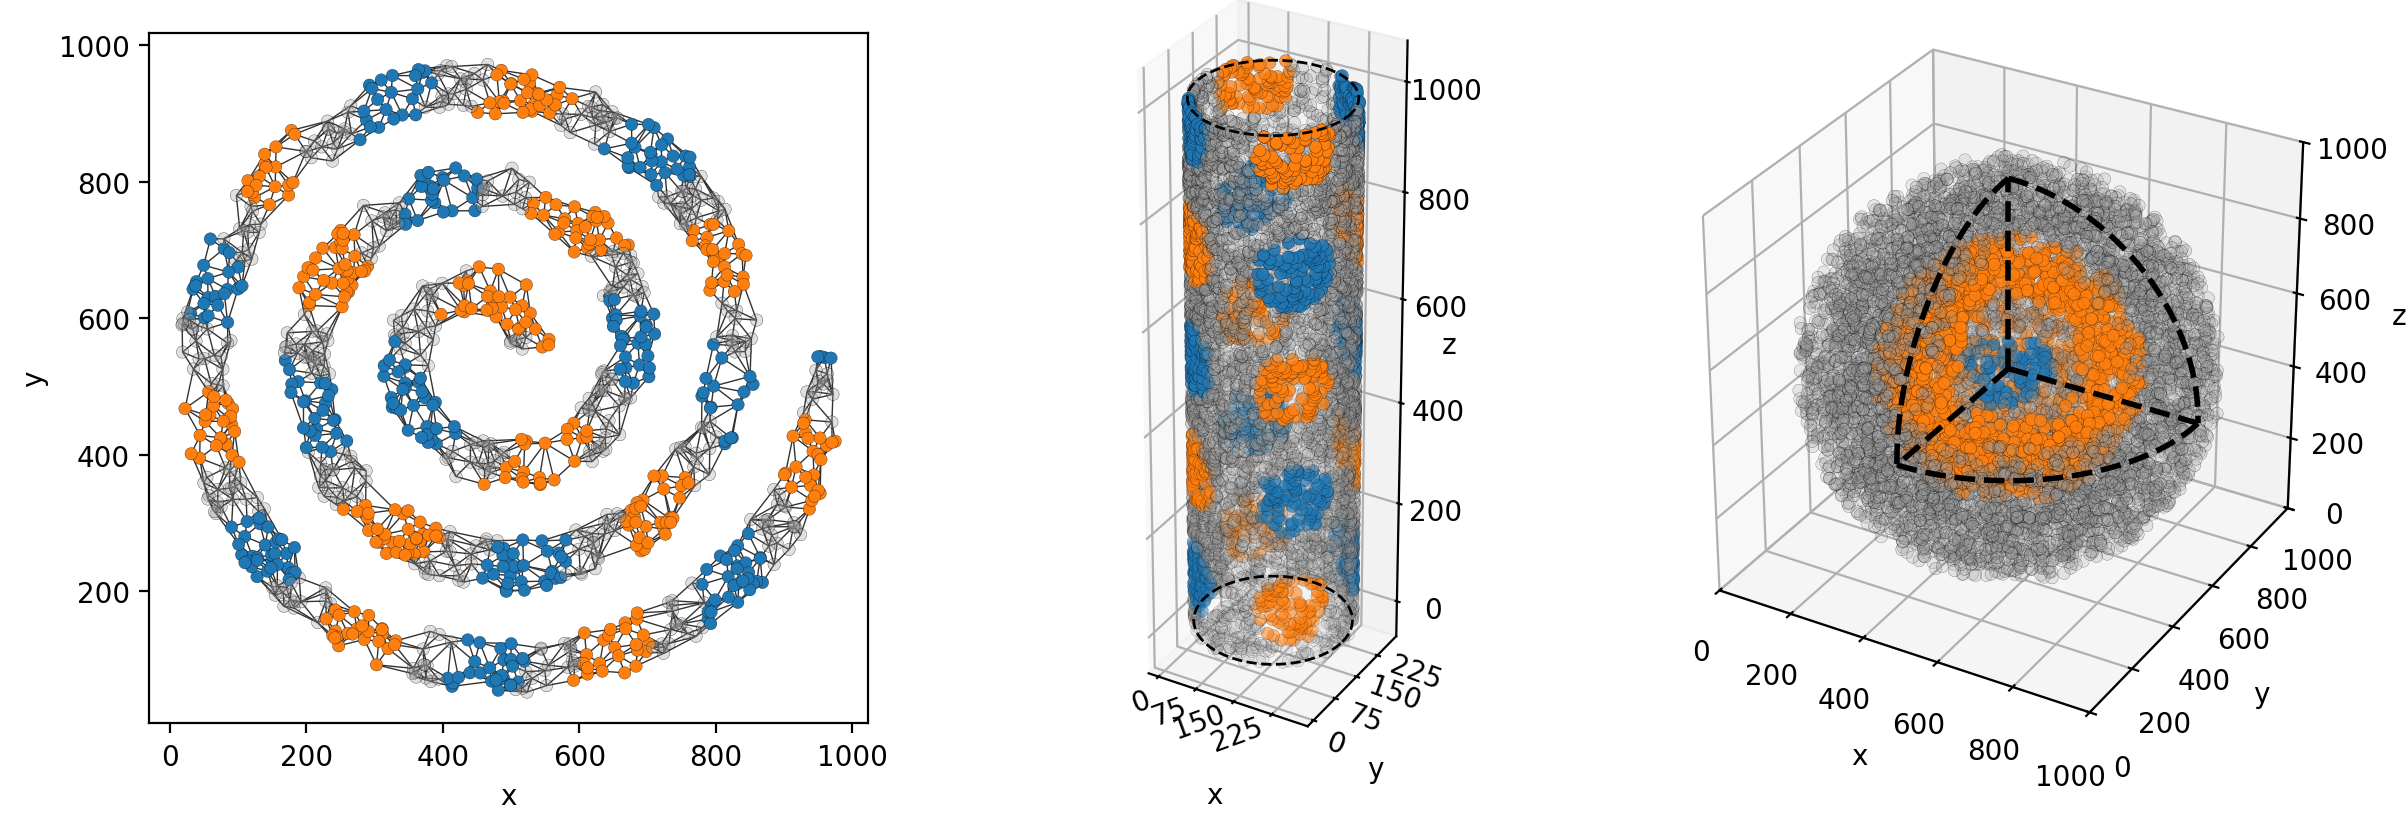

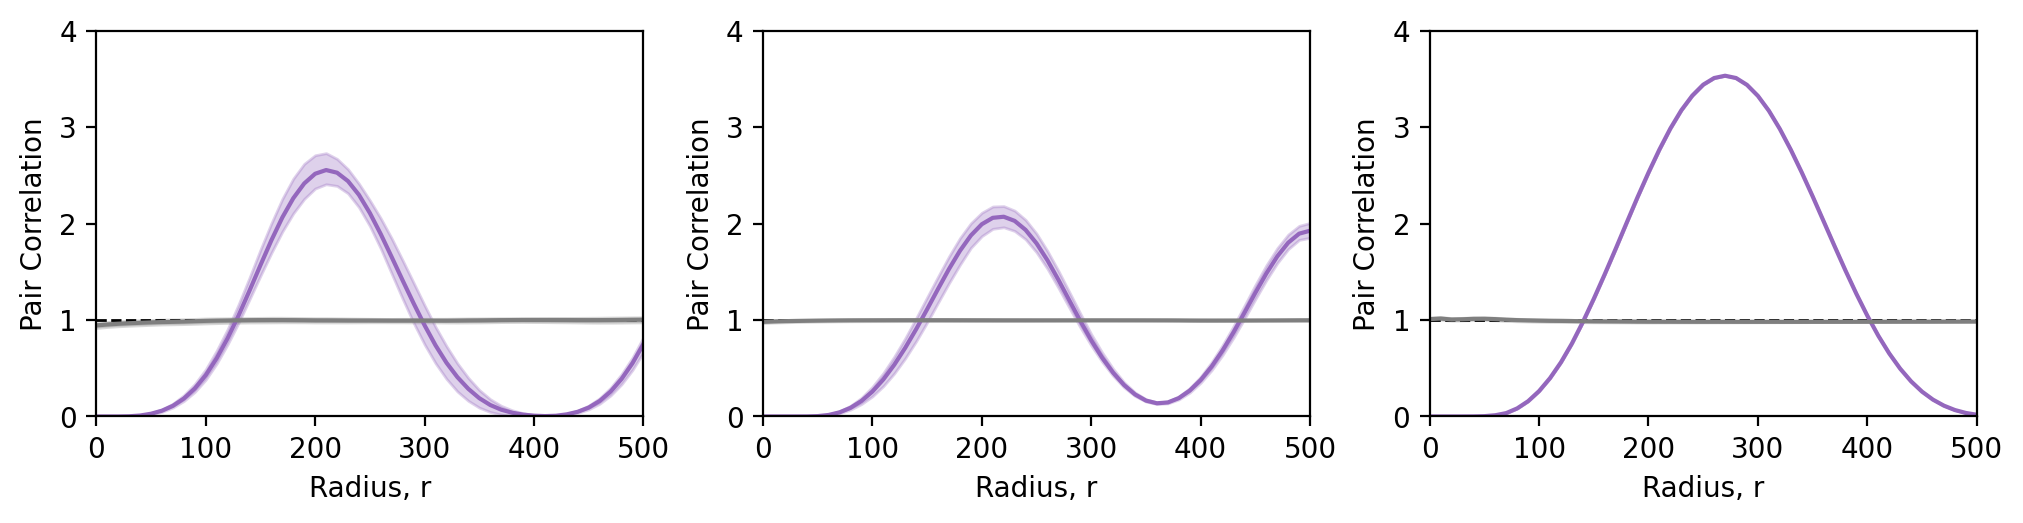

In [13]:
# just the categorical data
cat_a_color= mcolors.to_rgba('tab:blue')
cat_b_color= mcolors.to_rgba('tab:orange')
background_color = [0.6,0.6,0.6,0.3]  

fig1 = plt.figure(figsize=(12,9),constrained_layout=True)   
fig2 = plt.figure(figsize=(10,2.5),constrained_layout=True)   

### Spiral
ax1 = fig1.add_subplot(1, 3, 1)
sn.utils.plot_spatial_network(G_spiral,marker_size=0,edge_width=0.5,edge_weight_name=None,ax=ax1,scatter_kwargs=dict(cmap='PiYG',vmin=-1,vmax=1,linewidths=0.1,edgecolors='black'))

colors_cat_spiral=[]
for cat in periodic_labels_spiral:
    if cat == 'A':
        colors_cat_spiral.append(cat_a_color)
    elif cat == 'B':
        colors_cat_spiral.append(cat_b_color)
    else:
        colors_cat_spiral.append(background_color)
colors_cat_spiral = np.array(colors_cat_spiral) 
ax1.scatter(points_spiral[:,0],points_spiral[:,1],marker='o',s=20,edgecolors='black',linewidths=0.1,c=colors_cat_spiral,zorder=1000)


ax1.set_axis_on()
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')

ax2 = fig2.add_subplot(1, 3, 1)
ax2.axhline(1, linestyle='--', color='black', linewidth=1)

ax2.plot(r_spiral,g_spiral,color='tab:purple')
ax2.fill_between(r_spiral, CI_spiral[0,:], CI_spiral[1,:], color='tab:purple', alpha=0.3)


ax2.plot(r_spiral_back,g_spiral_back,color='tab:grey')
ax2.fill_between(r_spiral_back, CI_spiral_back[0,:], CI_spiral_back[1,:], color='tab:grey', alpha=0.3)

ax2.set_xlabel('Radius, r')
ax2.set_ylabel('Pair Correlation')
ax2.set_xlim([0, max_r])
ax2.set_ylim([0, 4])




### Cyclinder
ax5 = fig1.add_subplot(1, 3, 2, projection='3d')


colors_cat_cylinder=[]
for cat in pattern_along_cylinder_cat:
    if cat == 'A':
        colors_cat_cylinder.append(cat_a_color)
    elif cat == 'B':
        colors_cat_cylinder.append(cat_b_color)
    else:
        colors_cat_cylinder.append(background_color)
colors_cat_cylinder = np.array(colors_cat_cylinder) 


ax5.scatter(cylinder_points[:,0],cylinder_points[:,1],cylinder_points[:,2],marker='o',s=20,edgecolors='black',linewidths=0.1,c=colors_cat_cylinder,zorder=1000)

cy_theta = np.linspace(0, 2*np.pi, 100)    
ax5.plot(radius*np.cos(cy_theta)+radius,radius*np.sin(cy_theta)+radius,height*np.ones(len(cy_theta)),linestyle='--',color='black',linewidth=1,zorder=10000)
ax5.plot(radius*np.cos(cy_theta)+radius,radius*np.sin(cy_theta)+radius,0*np.ones(len(cy_theta)),linestyle='--',color='black',linewidth=1,zorder=1000)

ax5.set_axis_on()
ax5.set_xlabel('x',labelpad=-1)
ax5.set_ylabel('y',labelpad=-1)
ax5.set_zlabel('z')
ax5.set_aspect('equal')



xy_tick_labels = np.arange(0, 300, 75)
ax5.set_yticks(xy_tick_labels)
ax5.set_xticks(xy_tick_labels)
ax5.set_yticklabels(xy_tick_labels,rotation=-20,
                verticalalignment='baseline',
                horizontalalignment='left')
ax5.set_xticklabels(xy_tick_labels,rotation=20,
                verticalalignment='baseline',
                horizontalalignment='right')


ax5.tick_params(axis='x', which='major', pad=-0.5)
ax5.tick_params(axis='y', which='major', pad=-0.5)
ax5.tick_params(axis='z', which='major', pad=12)


ax6 = fig2.add_subplot(1, 3, 2)
ax6.axhline(1, linestyle='--', color='black', linewidth=1)
ax6.plot(r_cylinder,g_cylinder,color='tab:purple')
ax6.fill_between(r_cylinder, CI_cylinder[0,:], CI_cylinder[1,:], color='tab:purple', alpha=0.3)

ax6.plot(r_cylinder_back,g_cylinder_back,color='tab:grey')
ax6.fill_between(r_cylinder_back, CI_cylinder_back[0,:], CI_cylinder_back[1,:], color='tab:grey', alpha=0.3)

ax6.set_xlabel('Radius, r')
ax6.set_ylabel('Pair Correlation')
ax6.set_xlim([0, max_r])
ax6.set_ylim([0, 4])



### Sphere
mask = np.logical_and(filtered_points_sphere[:, 0] > length/2, filtered_points_sphere[:, 1] < length/2)  & (filtered_points_sphere[:, 2] > length/2)
mask = ~mask

ax9 = fig1.add_subplot(1, 3, 3, projection='3d')

colors_cat_sphere=[]
for cat in periodic_pattern_sphere_cat:
    if cat == 1:
        colors_cat_sphere.append(cat_a_color)
    elif cat == 2:
        colors_cat_sphere.append(cat_b_color)
    else:
        colors_cat_sphere.append(background_color)
colors_cat_sphere = np.array(colors_cat_sphere) 


mask_a = np.logical_and(mask,periodic_pattern_sphere_cat=='A')
mask_b = np.logical_and(mask,periodic_pattern_sphere_cat=='B')

ax9.scatter(filtered_points_sphere[mask, 0], filtered_points_sphere[mask, 1], filtered_points_sphere[mask, 2], 
            marker='o', s=20,linewidths=0.1, edgecolors='black',c=colors_cat_sphere[mask],vmin=1,vmax=10)



# wedge lines
theta = np.linspace(-np.pi/2, 0, 100)
phi= np.linspace(0, np.pi/2, 100)

ax9.plot((length/2) * np.cos(theta) + length/2, (length/2) * np.sin(theta) + length/2, length/2*np.ones(len(theta)), linestyle='--',color='black',linewidth=2,zorder=1000)
ax9.plot(length/2*np.ones(len(phi)), (length/2) * np.sin(-phi) + length/2, length/2*np.cos(phi)+length/2, linestyle='--',color='black',linewidth=2,zorder=1000)
ax9.plot((length/2) * np.sin(phi) + length/2, length/2*np.ones(len(phi)), length/2*np.cos(phi)+length/2, linestyle='--',color='black',linewidth=2,zorder=1000)
ax9.plot([length/2,length/2],[length/2,0],[length/2,length/2],linestyle='--',color='black',linewidth=2,zorder=1000)
ax9.plot([length/2,length],[length/2,length/2],[length/2,length/2],linestyle='--',color='black',linewidth=2,zorder=1000)
ax9.plot([length/2,length/2],[length/2,length/2],[length/2,length],linestyle='--',color='black',linewidth=2,zorder=1000)
ax9.set_aspect('equal')

# Set the limits and labels for better visualization
ax9.set_xlim([0, length])
ax9.set_ylim([0, length])
ax9.set_zlim([0, length])
ax9.set_xlabel('x')
ax9.set_ylabel('y')
ax9.set_zlabel('z')
ax9.set_aspect('equal')


ax10 = fig2.add_subplot(1, 3, 3)    
ax10.axhline(1, linestyle='--', color='black', linewidth=1)
ax10.plot(r_sphere,g_sphere,color='tab:purple')
ax10.fill_between(r_sphere, CI_sphere[0,:], CI_sphere[1,:], color='tab:purple', alpha=0.3)

ax10.plot(r_sphere_back,g_sphere_back,color='tab:grey')
ax10.fill_between(r_sphere_back, CI_sphere_back[0,:], CI_sphere_back[1,:], color='tab:grey', alpha=0.3)
ax10.set_xlabel('Radius, r')
ax10.set_ylabel('Pair Correlation')
ax10.set_xlim([0, max_r])
ax10.set_ylim([0, 4])
plt.draw()

#fig1.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/categorical_data_example_1.png',dpi=300)
#fig1.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/categorical_data_example_1.pdf',dpi=300)

#fig2.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/categorical_data_example_2.png',dpi=300)
#fig2.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/categorical_data_example_2.pdf',dpi=300)

### visualise domains and pcf curves (continuous)

/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/netPCF/spacenet/spacenet/utils/plot_spatial_network.py:230: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(points[:, 0], points[:, 1],color='grey', s=marker_size,zorder=100,**scatter_kwargs)


(0.0, 5.5)

/opt/miniconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)


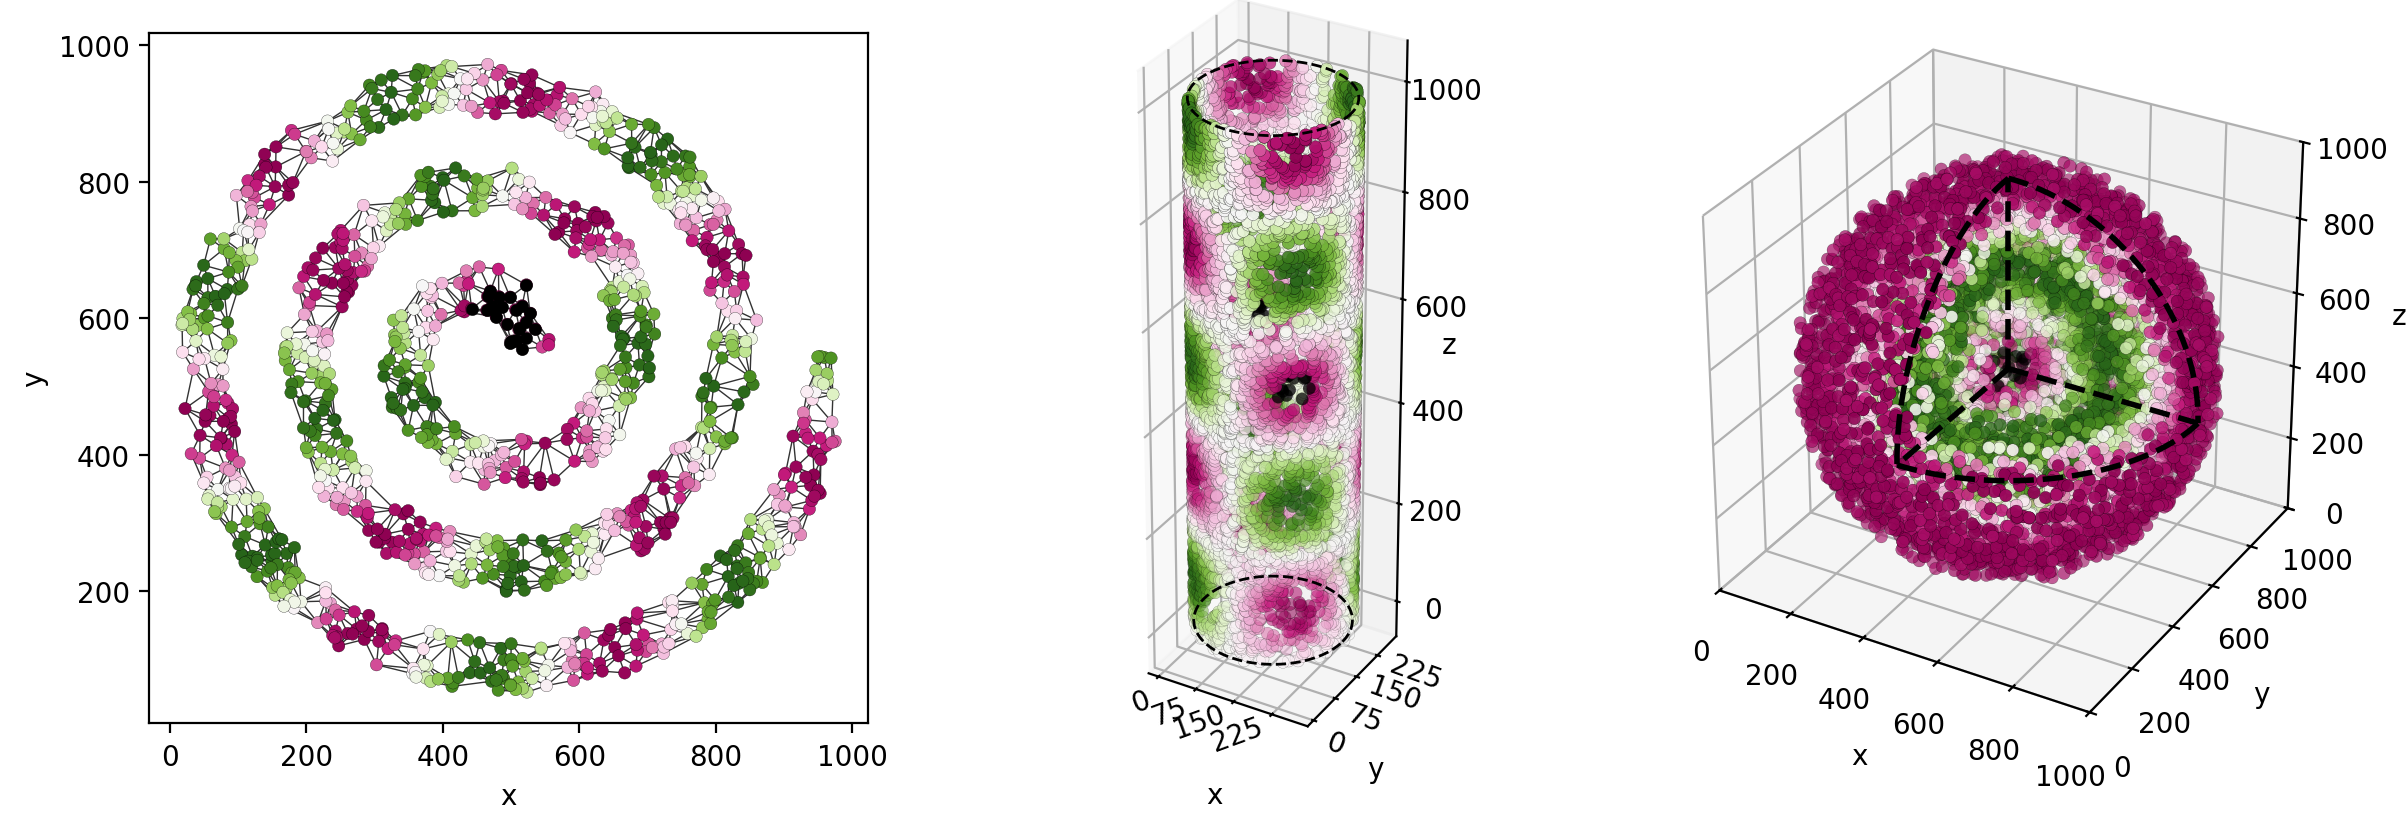

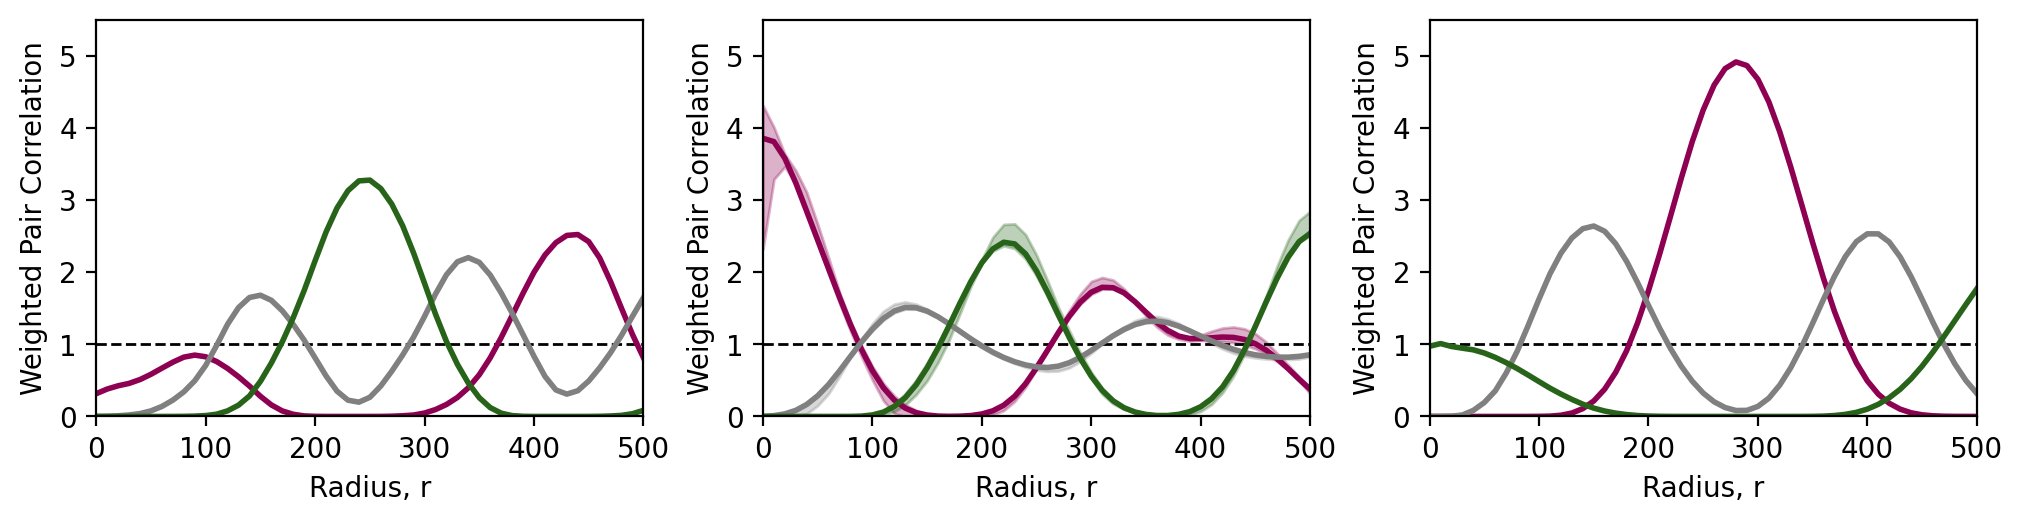

In [28]:

# setting up colors
cylinder_colors_continuous = []
for i, val in enumerate(pattern_along_cylinder):
    if i in nodes_at_low_cyclinder:
        cylinder_colors_continuous.append([0,0,0,1])
    else:
        cylinder_colors_continuous.append(plt.cm.PiYG((val+1)/2))  # Normalize to [0, 1] for colormap
cylinder_colors_continuous = np.array(cylinder_colors_continuous)


sphere_colors_continuous = []   
for i, val in enumerate(-periodic_pattern_sphere):
    if i in nodes_in_center:
        sphere_colors_continuous.append([0,0,0,1])
    else:
        sphere_colors_continuous.append(plt.cm.PiYG((val+1)/2))  # Normalize to [0, 1] for colormap
sphere_colors_continuous = np.array(sphere_colors_continuous)

cat_a_color= mcolors.to_rgba('tab:blue')
cat_b_color= mcolors.to_rgba('tab:orange')
background_color = [0.6,0.6,0.6,0.3]  



fig1 = plt.figure(figsize=(12,9),constrained_layout=True)   
fig2 = plt.figure(figsize=(10,2.5),constrained_layout=True)   

### Spiral

ax3 = fig1.add_subplot(1, 3, 1)
sn.utils.plot_spatial_network(G_spiral,marker_size=0,edge_width=0.5,edge_weight_name=None,ax=ax3,scatter_kwargs=dict(cmap='PiYG',vmin=-1,vmax=1,linewidths=0.1,edgecolors='black'))
ax3.scatter(points_spiral[:,0],points_spiral[:,1],marker='o',s=20,c=periodic_labels_spiral_cont,zorder=500,cmap='PiYG',vmin=-1,vmax=1,linewidths=0.1,edgecolors='black')

ax3.scatter(points_spiral[centre_nodes_spiral,0],points_spiral[centre_nodes_spiral,1],marker='o',s=20,edgecolors='black',linewidths=0.1,color='black',zorder=1000)
ax3.set_axis_on()
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_aspect('equal')

ax4 = fig2.add_subplot(1, 3, 1)
ax4.axhline(1, linestyle='--', color='black', linewidth=1)
cont_colormap=plt.cm.PiYG(np.linspace(0,1,len(tau_spiral_cont)))
for i, tau in enumerate(tau_spiral_cont):
    if tau==0:
        color='grey'
    else: 
        color=cont_colormap[i]
    ax4.fill_between(r_spiral_cont,CI_spiral_cont[0,i,:],CI_spiral_cont[1,i,:],color=color,alpha=0.3)
    ax4.plot(r_spiral_cont,g_spiral_cont[i,:],color=color,linewidth=2,label='$\\tau_{B}=$'+f'{tau:.2f}')   

ax4.set_xlabel('Radius, r')
ax4.set_ylabel('Weighted Pair Correlation')
ax4.set_xlim([0, max_r])
ax4.set_ylim([0, 5.5])


### Cyclinder
ax7 = fig1.add_subplot(1, 3, 2, projection='3d')

ax7.scatter(cylinder_points[:,0],cylinder_points[:,1],cylinder_points[:,2],c=cylinder_colors_continuous,s=20,edgecolors='black',linewidths=0.1,zorder=1000)

ax7.plot(radius*np.cos(cy_theta)+radius,radius*np.sin(cy_theta)+radius,height*np.ones(len(cy_theta)),linestyle='--',color='black',linewidth=1,zorder=10000)
ax7.plot(radius*np.cos(cy_theta)+radius,radius*np.sin(cy_theta)+radius,0*np.ones(len(cy_theta)),linestyle='--',color='black',linewidth=1,zorder=1000)


ax7.set_axis_on()
ax7.set_xlabel('x',labelpad=-1)
ax7.set_ylabel('y',labelpad=-1)
ax7.set_zlabel('z')
ax7.set_aspect('equal')


xy_tick_labels = np.arange(0, 300, 75)
ax7.set_yticks(xy_tick_labels)
ax7.set_xticks(xy_tick_labels)
ax7.set_yticklabels(xy_tick_labels,rotation=-20,
                verticalalignment='baseline',
                horizontalalignment='left')
ax7.set_xticklabels(xy_tick_labels,rotation=20,
                verticalalignment='baseline',
                horizontalalignment='right')


ax7.tick_params(axis='x', which='major', pad=-0.5)
ax7.tick_params(axis='y', which='major', pad=-0.5)
ax7.tick_params(axis='z', which='major', pad=12)


ax8 = fig2.add_subplot(1, 3, 2)
ax8.axhline(1, linestyle='--', color='black', linewidth=1)
cont_colormap=plt.cm.PiYG(np.linspace(0,1,len(tau_spiral_cont)))
for i, tau in enumerate(tau_spiral_cont):
    if tau==0:
        color='grey'
    else: 
        color=cont_colormap[i]
    ax8.fill_between(r_cyclinder_cont,CI_cyclinder_cont[0,i,:],CI_cyclinder_cont[1,i,:],color=color,alpha=0.3)
    ax8.plot(r_cyclinder_cont,g_cyclinder_cont[i,:],color=color,linewidth=2,label='$\\tau_{B}=$'+f'{tau:.2f}') 
  

ax8.set_xlabel('Radius, r')
ax8.set_ylabel('Weighted Pair Correlation')
ax8.set_xlim([0, max_r])
ax8.set_ylim([0, 5.5])



### Sphere


mask = np.logical_and(filtered_points_sphere[:, 0] > length/2, filtered_points_sphere[:, 1] < length/2)  & (filtered_points_sphere[:, 2] > length/2)
mask = ~mask

ax11 = fig1.add_subplot(1, 3, 3, projection='3d')

# Plot the filtered points in 3D
ax11.scatter(filtered_points_sphere[mask, 0], filtered_points_sphere[mask, 1], filtered_points_sphere[mask, 2], 
            c=sphere_colors_continuous[mask], marker='o', s=20,linewidths=0.1, edgecolors='black')
# wedge lines
theta = np.linspace(-np.pi/2, 0, 100)
phi= np.linspace(0, np.pi/2, 100)

ax11.plot((length/2) * np.cos(theta) + length/2, (length/2) * np.sin(theta) + length/2, length/2*np.ones(len(theta)), linestyle='--',color='black',linewidth=2,zorder=1000)
ax11.plot(length/2*np.ones(len(phi)), (length/2) * np.sin(-phi) + length/2, length/2*np.cos(phi)+length/2, linestyle='--',color='black',linewidth=2,zorder=1000)
ax11.plot((length/2) * np.sin(phi) + length/2, length/2*np.ones(len(phi)), length/2*np.cos(phi)+length/2, linestyle='--',color='black',linewidth=2,zorder=1000)
ax11.plot([length/2,length/2],[length/2,0],[length/2,length/2],linestyle='--',color='black',linewidth=2,zorder=1000)
ax11.plot([length/2,length],[length/2,length/2],[length/2,length/2],linestyle='--',color='black',linewidth=2,zorder=1000)
ax11.plot([length/2,length/2],[length/2,length/2],[length/2,length],linestyle='--',color='black',linewidth=2,zorder=1000)
ax11.set_aspect('equal')
# Set the limits and labels for better visualization
ax11.set_xlim([0, length])
ax11.set_ylim([0, length])
ax11.set_zlim([0, length])
ax11.set_xlabel('x')
ax11.set_ylabel('y')
ax11.set_zlabel('z')
ax11.set_aspect('equal')


ax12 = fig2.add_subplot(1, 3, 3)

ax12.axhline(1, linestyle='--', color='black', linewidth=1)
cont_colormap=plt.cm.PiYG(np.linspace(0,1,len(tau_spiral_cont)))
for i, tau in enumerate(tau_spiral_cont):
    if tau==0:
        color='grey'
    else: 
        color=cont_colormap[i]
    ax12.fill_between(r_sphere_cont,CI_sphere_cont[0,i,:],CI_sphere_cont[1,i,:],color=color,alpha=0.3)
    ax12.plot(r_sphere_cont,g_sphere_cont[i,:],color=color,linewidth=2,label='$\\tau_{B}=$'+f'{tau:.2f}')   

ax12.set_xlabel('Radius, r')
ax12.set_ylabel('Weighted Pair Correlation')
ax12.set_xlim([0, max_r])
ax12.set_ylim([0, 5.5])

#fig1.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/continuous_data_example_1.png',dpi=300)
#fig1.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/continuous_data_example_1.pdf',dpi=300)

#fig2.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/continuous_data_example_2.png',dpi=300)
#3fig2.savefig('/Users/joshuamoore/Dropbox/Ox_PostDoc/Method_development/netPCF_paper/scripts_for_manuscript/figures/continuous_data_example_2.pdf',dpi=300)